In [38]:
!pip install qiskit qiskit-aer qiskit[visualization]

In [39]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from itertools import islice

In [40]:
# Initialize quantum circuit with one qubit and one classical bit
circ = QuantumCircuit(1, 1)

# Apply Hadamard gate to qubit at the index 0
circ.h(0)

# Measure the qubit at index 0 and store in the classical bit at index 0
circ.measure(0,0)

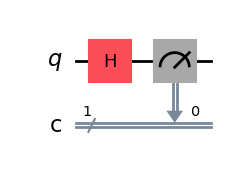

In [41]:
# Draw the quantum circuit using matplotlib
circ.draw("mpl")

In [42]:
print("Details of Classical Register: ", circ.cregs)
# Details of Classical Register:  [ClassicalRegister(1, 'c')]

print("Details of Quantum Register: ", circ.qregs)
# Details of Quantum Register:  [QuantumRegister(1, 'q')]

Details of Classical Register:  [ClassicalRegister(1, 'c')]
Details of Quantum Register:  [QuantumRegister(1, 'q')]


In [43]:
# Initializing the simulator
backend = AerSimulator()

# Transpile 
circ = transpile(circ, backend)

In [44]:
BITS = 32
NUMBERS = 10000

In [45]:
# Run the simulator 640000 times to generate 10000 64-bit number
result = backend.run(circ, shots=BITS*NUMBERS, memory=True).result()

# Extract the results from memory in a list and print them
memory = result.get_memory(circ)
# print("memory", memory)

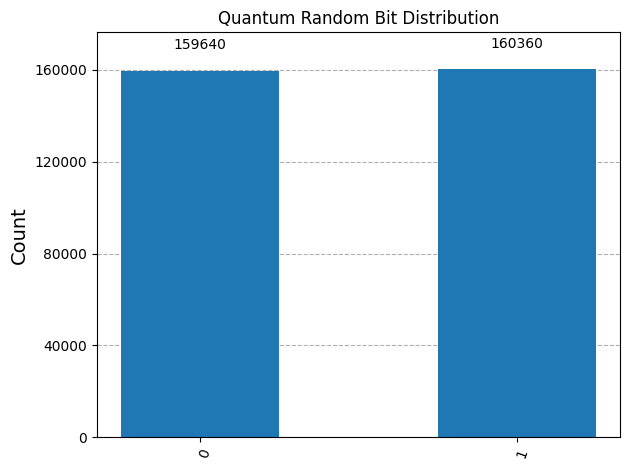

In [46]:
# Get the data of our experiment
counts = result.get_counts(circ)

# Plot the data in a histogram
plot_histogram(counts, title='Quantum Random Bit Distribution')

In [47]:
def save_binary_list_to_file(memory_list, filename='output.bin'):
    """
    Convert a list of binary strings ('0', '1') into a binary file.
    Groups bits into 8-bit bytes and writes them as binary data.
    """
    # Join all bits into a single string
    binary_string = ''.join(memory_list)
    
    # Pad with zeros on the right if not divisible by 8
    padding = (8 - len(binary_string) % 8) % 8
    binary_string += '0' * padding
    
    # Convert each 8-bit chunk to a byte and write to file
    with open(filename, 'wb') as f:
        for i in range(0, len(binary_string), 8):
            byte_string = binary_string[i:i+8]
            byte_value = int(byte_string, 2)  # Convert binary string to integer
            f.write(bytes([byte_value]))
    
    print(f"Written {len(binary_string) // 8} bytes to {filename}")


In [48]:
save_binary_list_to_file(memory, 'simulated.bin')

Written 40000 bytes to simulated.bin
